In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT
from python_files import ETLM_code as ETLMC







  0%|          | 0/3000 [00:00<?, ?it/s]/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_6942/164074543.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
100%|██████████| 3000/3000 [01:11<00:00, 41.94it/s]


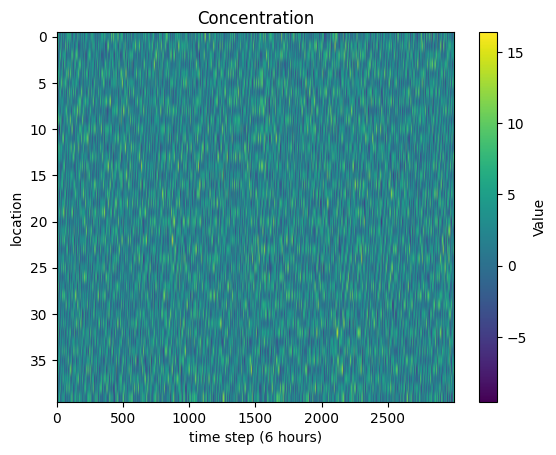

In [2]:
# In this cell we want to run the Lorenz 96 model 
# We also want to save the outputs to a folder so we can verify the spin up

#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  3000   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

# We now set our initial state vector
x = torch.randn(N)


trajectory = []
times = []
dust_mass = []

t = 0.0
x_values = np.arange(1, N+1)  
for i in tqdm(range(timesteps)):
    # print(i)
    plt.title(f' Lorenz 96 after time step = {i:.2f}')
    plt.plot(x_values, x)
    plt.legend()
    # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # /Users/imilesfine/PhD Work2026/Lorenz_basic
    plt.clf()



    trajectory.append(x.clone())  # store current state
    times.append(t)
    
    x = bf.crank_nicolson_L96(x, model_parameters)
    t += dt


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T




plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Concentration")
plt.show()


In [3]:
# We then want to find the ETLM of L96
ensemble_size = 90
sd = 10**(-7)
model = bf.crank_nicolson_L96

# We first need to spin up the model
x_0 = torch.randn(N)
x = ETLMC.spin_up(x, model_parameters, model)
x_g = x



ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)

100%|██████████| 90/90 [00:00<00:00, 1704.16it/s]


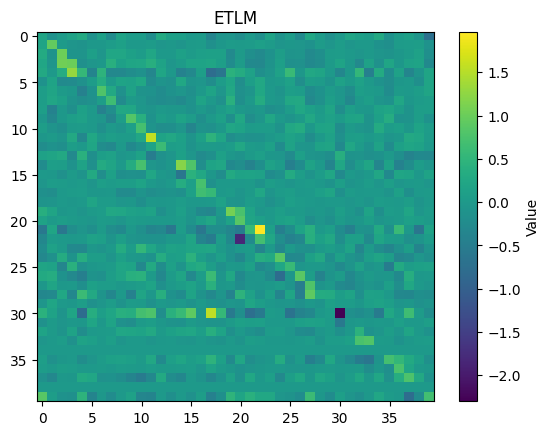

In [4]:
plt.imshow(ETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("ETLM")
plt.show()


In [5]:
# We will find the Jacobian now using Pytorch's autograd function
# We will use the Pytorch autograd function to find the Jacobian of the Lorenz 96 model
y = x_g.clone().detach().requires_grad_(True)

J = torch.autograd.functional.jacobian(
    lambda y: model(y, model_parameters),
    y
)
print(J.shape)

torch.Size([40, 40])


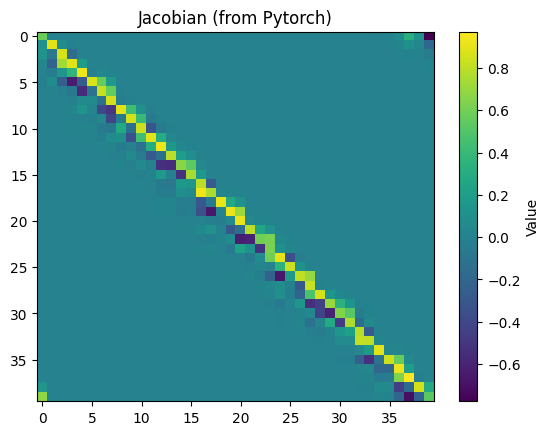

In [6]:
plt.imshow(J,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Jacobian (from Pytorch)")
plt.show()


tensor(40.0000)


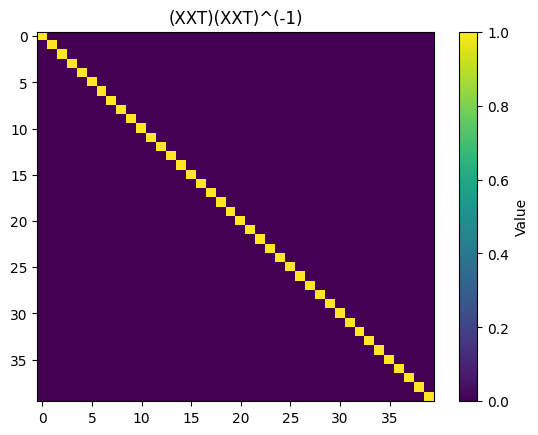

In [7]:
# We will run the following tests

# M X_i = X_{i+1}
# print(torch.sum(abs(ETLM @ X - Chi))/(N**2))


# Verify that the 'inverse' is actually the inverse by seeing if it gives the identity

A = torch.matmul(X,  torch.transpose(X,0,1))
A_inv = torch.linalg.inv( torch.matmul(X,  torch.transpose(X,0,1)))
print(torch.trace(A@A_inv))
# print(torch.sum(abs(A@A_inv)))
plt.imshow(A@A_inv,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("(XXT)(XXT)^(-1)")
plt.show()

In [8]:
# We will start by defining our error function
def norm_error(x_g,x_pert, model, M, model_parameters):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
    return diff


def normalisor(x_g, model_parameters, M, model):
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    norm = x_out_pert - x_out_unpert
    return norm

def alt_TLM_test(x_g, x_pert, model_parameters, M, model):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = sum(abs(x_out_pert - x_out_unpert - torch.matmul(M, x_pert)))
    average = sum(abs(x_pert))
    return (diff/average)/N
    

# We will now define a very quick generic TLM test that will be used for the multistep TLM test 
def generic_TLM_test(diff, norm):
    error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
    return error

In [9]:
# We will then perform the TLM test
sd = 10**(-4)

x_pert = torch.randn(N) * sd

diff = norm_error(x_g, x_pert, model, ETLM, model_parameters)
norm = normalisor(x_g, model_parameters, ETLM, model)

TLM_test_result = generic_TLM_test(diff, norm)
print(TLM_test_result)


error = alt_TLM_test(x_g, x_pert, model_parameters, ETLM, model)
print(error)

1.2362541670772418
tensor(0.0348)


/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_6942/463317296.py:30: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))


In [10]:
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results = []
trials = 50
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    print(-i)
    ensemble_size = 150
    model = bf.crank_nicolson_L96

    # We first need to spin up the model
    x_0 = torch.randn(N)
    x = ETLMC. spin_up(x, model_parameters, model)
    x_g = x
    ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N) * sd

        diff = norm_error(x_g, x_pert, model, ETLM, model_parameters)
        norm = normalisor(x_g, model_parameters, ETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, ETLM, model)
    results.append(error/trials)
    

    

0


100%|██████████| 150/150 [00:00<00:00, 1732.25it/s]


-1


100%|██████████| 150/150 [00:00<00:00, 1765.69it/s]


-2


...

100%|██████████| 150/150 [00:00<00:00, 1489.60it/s]


-9


100%|██████████| 150/150 [00:00<00:00, 1753.63it/s]


-10


100%|██████████| 150/150 [00:00<00:00, 1703.88it/s]


In [11]:
# We will now do the same for the Jacobian generated by the pytorch function 
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_pytorch = []
trials = 50
for i in perturbations:
    sd = 10**(-1* i)
    ensemble_size = 150
    model = bf.crank_nicolson_L96

    # We first need to spin up the model
    # x_0 = torch.randn(N)
    # x = ETLMC. spin_up(x, model_parameters, model)
    # x_g = x
    # ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)

    y = x_g.clone().detach().requires_grad_(True)

    J = torch.autograd.functional.jacobian(lambda y: model(y, model_parameters),y)

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N) * sd

        diff = norm_error(x_g, x_pert, model, J, model_parameters)
        norm = normalisor(x_g, model_parameters, J, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, J, model)
    results_pytorch.append(error/trials)

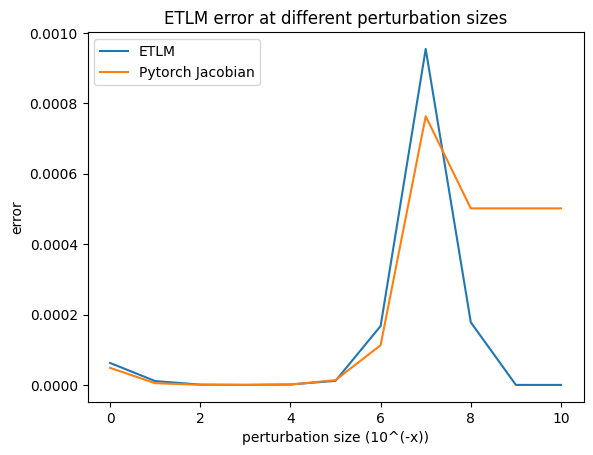

[tensor(6.2408e-05), tensor(1.0974e-05), tensor(8.0887e-07), tensor(1.6548e-07), tensor(1.2302e-06), tensor(1.1568e-05), tensor(0.0002), tensor(0.0010), tensor(0.0002), tensor(0.), tensor(0.)]


In [12]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes')
plt.legend()

plt.show()
print(results)

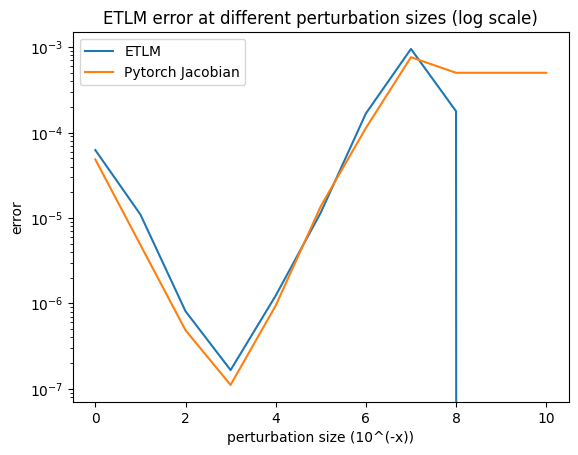

In [13]:
plt.yscale('log') # This is base 10
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

100%|██████████| 90/90 [00:00<00:00, 1686.48it/s]


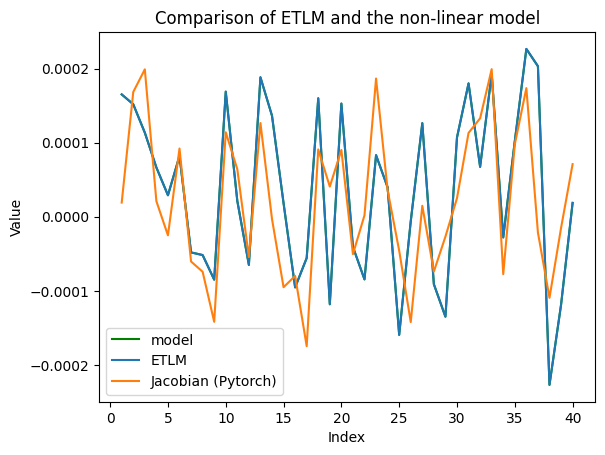

In [14]:
sd = 10**(-4)
# We then want to find the ETLM of L96
ensemble_size = 90
model = bf.crank_nicolson_L96

# We first need to spin up the model
x_0 = torch.randn(N)
x = ETLMC.spin_up(x, model_parameters, model)
x_g = x



ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)
x_pert = torch.randn(N) * sd
# Plot the two curves
base = range(1, 41)
x_in_pert = x_g + x_pert
x_out_pert = model(x_in_pert, model_parameters)
x_out_unpert = model(x_g, model_parameters)
diff = x_out_pert - x_out_unpert 
other =  torch.matmul((ETLM), x_pert)
Other_jacobian = torch.matmul(J, x_pert)


plt.plot(base, diff, label = 'model', color = 'g')
plt.plot(base, other,label = 'ETLM' )
plt.plot(base, Other_jacobian,label = 'Jacobian (Pytorch)' )
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Comparison of ETLM and the non-linear model')
plt.legend()

plt.show()

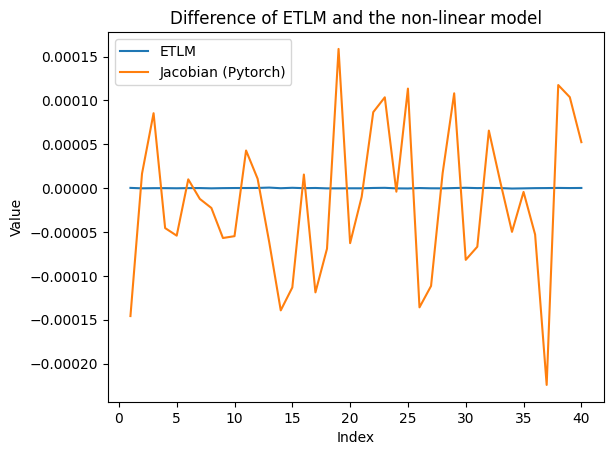

In [15]:
plt.plot(base, other- diff,label = 'ETLM' )
plt.plot(base,Other_jacobian - diff, label = 'Jacobian (Pytorch)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Difference of ETLM and the non-linear model')
plt.legend()

plt.show()

In [16]:
# We will now see what happens if we set everything on not on the tridiagonal to be zero
def zeronator(N, matrix):
    matrix_copy = matrix.clone().detach()
    for i in tqdm(range(N)):
        for j in range(N):
            if abs(i-j) > 5:
               matrix_copy[i,j] = 0
    return matrix_copy


100%|██████████| 40/40 [00:00<00:00, 19350.88it/s]


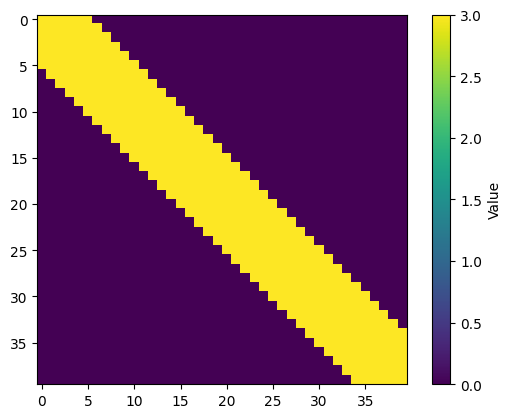

In [17]:
# We will now test this function
N = 40
test_matrix = torch.full((40, 40), 3)
test_zeros = zeronator(N, test_matrix)
plt.imshow(test_zeros, cmap='viridis')
plt.colorbar(label='Value')

plt.show()


In [18]:
# We will now 'localise' the ETLM
ETLM_local = zeronator(N, ETLM)

100%|██████████| 40/40 [00:00<00:00, 18076.95it/s]


In [19]:
# We will now run the tests again and see if there is an increase in accuracy.
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_local3 = []
trials = 50
for i in perturbations:
    sd = 10**(-1*perturbations[i])
    ensemble_size = 150
    model = bf.crank_nicolson_L96

    # We first need to spin up the model
    x_0 = torch.randn(N)
    x = ETLMC. spin_up(x, model_parameters, model)
    x_g = x
    ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model, local = True)

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N) * sd

        diff = norm_error(x_g, x_pert, model, ETLM, model_parameters)
        norm = normalisor(x_g, model_parameters, ETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, ETLM, model)
    results_local3.append(error/trials)
    

    

100%|██████████| 40/40 [00:00<00:00, 14193.92it/s]


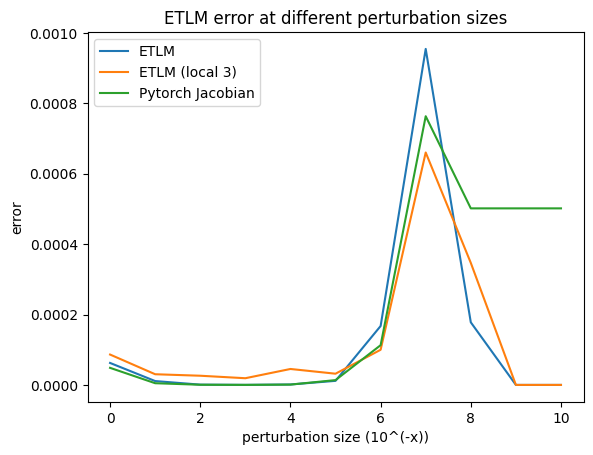

[tensor(6.2408e-05), tensor(1.0974e-05), tensor(8.0887e-07), tensor(1.6548e-07), tensor(1.2302e-06), tensor(1.1568e-05), tensor(0.0002), tensor(0.0010), tensor(0.0002), tensor(0.), tensor(0.)]


In [20]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local3,label = 'ETLM (local 3)' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes')
plt.legend()

plt.show()
print(results)

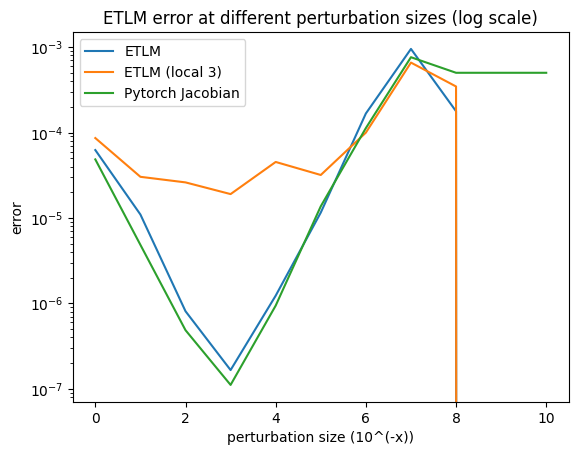

In [21]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local3,label = 'ETLM (local 3)' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

In [22]:
# I am now going to try make the LETLM of the Lorenz 96 Model that is timestepped with RK4

# We we are going to start by generating the ensemble members
def ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time):
    # we first extract the model variables
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    # we now run the model to spin up the model
    x_in = torch.rand((N,1))
    results = x_in
    for i in range(spin_up_time):
        x_out = model(x_in, model_parameters)
        results = torch.cat((results, x_out), dim = 1)
        x_in = x_out

    # We will create the tensors to hold the ensembles
    number_of_variables =  N # n = number of varables at each point and N = number of points
    Xi = torch.zeros(number_of_variables, ensemble_size)
    X = torch.zeros(number_of_variables, ensemble_size)
    Chi = torch.zeros(number_of_variables, ensemble_size)

    for i in range(ensemble_size):
        x_pert = torch.randn(number_of_variables,1) * perturbation_size
        x_in_pert = x_out + x_pert
        x_out_pert = model(x_in_pert,model_parameters)
        x_out_unpert = model(x_out, model_parameters)
        Xi_i = x_out_pert - x_out_unpert
        X[:,i] = x_pert.squeeze()
        Xi[:,i] = Xi_i.squeeze()
        x_out_pert = model(x_in_pert,model_parameters)
        x_out_unpert = model(x_out, model_parameters)
        Chi_i = x_out_pert - x_out_unpert
        Chi[:,i] = Chi_i.squeeze()
    return X, Xi, Chi
    

In [23]:
# We will now test this function
# We start by setting the parameters that we need
# We will start with the model parameters
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_L96)
ensemble_size = 12
model = bf.crank_nicolson_L96
spin_up_time = 1000
perturbation_size = 10**(-3)



X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

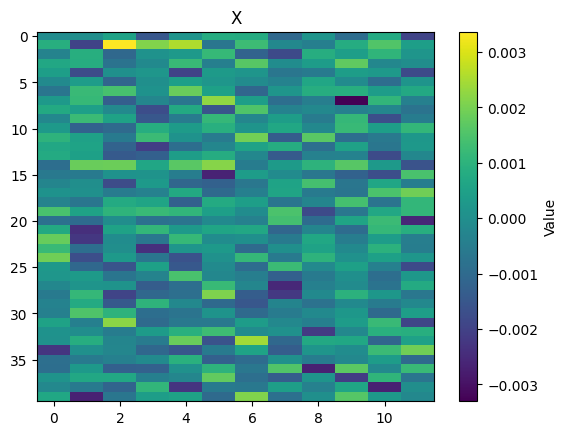

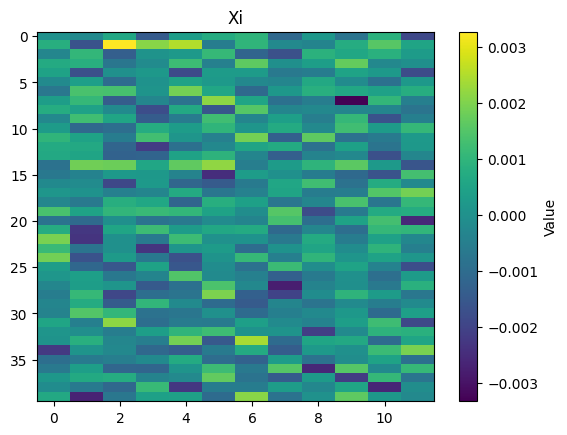

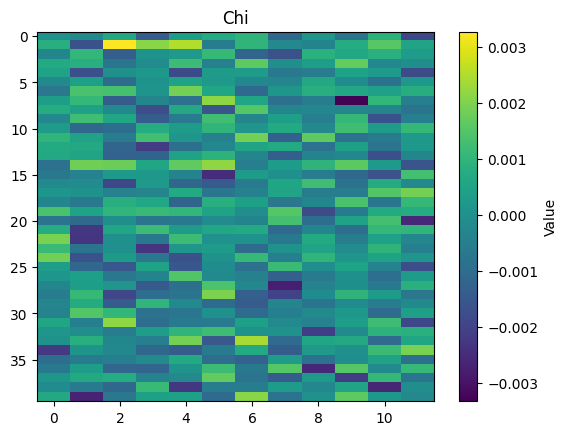

In [24]:
# We will now plot the function
plt.imshow(X.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()
plt.imshow(Xi.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Xi")
plt.show()
plt.imshow(Chi.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Chi")
plt.show()


In [25]:
# We will now define a function that selects the 9 members of each row 
def member_past_selector(grid_index,X,N,ensemble_size):
    subset = torch.zeros(9,ensemble_size)
    for i in range(9):
        j = (grid_index +i - 4)%N
        # print(grid_index, j)
        subset[i,:] = X[j,:]
    return subset

In [26]:
# We will now test this functiom
N = 40
ensemble_size = 12

# Row i contains only the value i
X = torch.zeros(N, ensemble_size)

for i in range(N):
    X[i, :] = i

print(X)


tensor([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
        [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
        [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.],
        [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.],
        [ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.],
        [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.],
        [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.],
        [ 8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.],
        [ 9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.],
        [10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.],
        [11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11., 11.],
        [12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12., 12.],
        [13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13., 13.],
        [14., 14., 1

In [27]:
subset = member_past_selector(
    grid_index=37,
    X=X,
    N=N,
    ensemble_size=ensemble_size
)

print(subset)
# The test appears to show that the function is working

tensor([[33., 33., 33., 33., 33., 33., 33., 33., 33., 33., 33., 33.],
        [34., 34., 34., 34., 34., 34., 34., 34., 34., 34., 34., 34.],
        [35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.],
        [36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.],
        [37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37., 37.],
        [38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38.],
        [39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.]])


In [28]:
def member_current_selector(grid_index,Xi,N,ensemble_size):
    subset = torch.zeros(1,ensemble_size)
    j = grid_index
    subset[0,:] = Xi[j,:]
    # print(subset.shape)
    return subset





In [29]:
# We will now test this function to make sure it works
subset = member_current_selector(
    grid_index=0,
    Xi=X,
    N=N,
    ensemble_size=ensemble_size
)

print(subset)
# This function appears to work

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


In [30]:
def little_LETLM(current_subset, past_subset):
    etlm = current_subset @ past_subset.T@(torch.inverse(past_subset@ past_subset.T))
    return etlm


In [31]:
#  We will now test that this function returns the right shape
subset = member_past_selector(38,X,N,ensemble_size)
print(subset.shape)


torch.Size([9, 12])


In [32]:
# # We will now define a function that puts M_i into M 
# def put_in_place(M_i, N, M, i):
#     M_i = M_i.squeeze()
#     # M_i = [1,2,3,4,5,6,7,8,9]

#     for k in range(9):
#         j = k -4 + i
#         # print(k,j)
#         # print(i,j)
#         # print(M_i.shape)
#         # print(M_i[k].shape)
#         # M[j%N,i] = M_i[k]
#         M[j % N, i] = M_i[::-1][k]

#     return M

def put_in_place(M_i, N, M, i):
    M_i = M_i.squeeze()
    # For debugging use this test tensor
    # M_i = torch.tensor([1,2,3,4,5,6,7,8,9])

    M_i_reversed = torch.flip(M_i, dims=[0])

    for k in range(9):
        j = k - 4 + i
        M[j % N, i] = M_i_reversed[k]

    return M


In [33]:
def LETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    # We start by generating the ensemble members
    X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)
    # We now create an empty tensor that will become our M matrix
    M = torch.zeros(N,N)
    # We now need to calculate the LETLM for each variable in the model 
    for i in tqdm(range(N)):
        # The first step is to select the required ensemble members:
        # We start with the past time step 
        X_i = member_past_selector(i,X,N,ensemble_size)
        # Now the current time step
        Xi_i = member_current_selector(i,Xi,N,ensemble_size)
        # print(X_i.shape)
        
        # We now calculate the local LETLM
        M_i = little_LETLM(Xi_i, X_i)
        # print(M_i.shape)

        # We now need to put M_i into the correct position in M
        M = put_in_place(M_i, N, M, i)
    return M
        


        
        

In [34]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_L96)
ensemble_size = 12
model = bf.crank_nicolson_L96
spin_up_time = 1000
perturbation_size = 10**(-3)
LETLM = LETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

100%|██████████| 40/40 [00:00<00:00, 16435.36it/s]


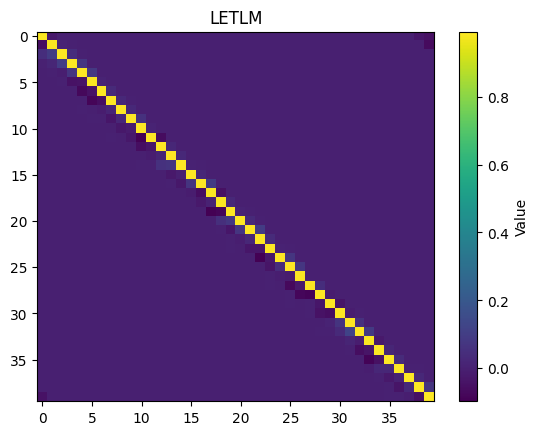

tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  2.1029e-04, -2.7432e-03, -2.4509e-02, -1.5482e-03,
         9.9064e-01,  2.2636e-02, -2.0357e-03, -8.8096e-05, -1.2076e-04,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00])


In [35]:
plt.imshow(LETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("LETLM")
plt.show()
print(LETLM[15])

In [36]:
# We will now run the tests again and see if there is an increase in accuracy.
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_local = []
trials = 50
for i in perturbations:
    sd = 10**(-1*perturbations[i])
    ensemble_size = 12
    model = bf.crank_nicolson_L96

    # We first need to spin up the model
    LETLM = LETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N) * sd

        diff = norm_error(x_g, x_pert, model, LETLM, model_parameters)
        norm = normalisor(x_g, model_parameters, LETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, LETLM, model)
    results_local.append(error/trials)

100%|██████████| 40/40 [00:00<00:00, 16912.52it/s]


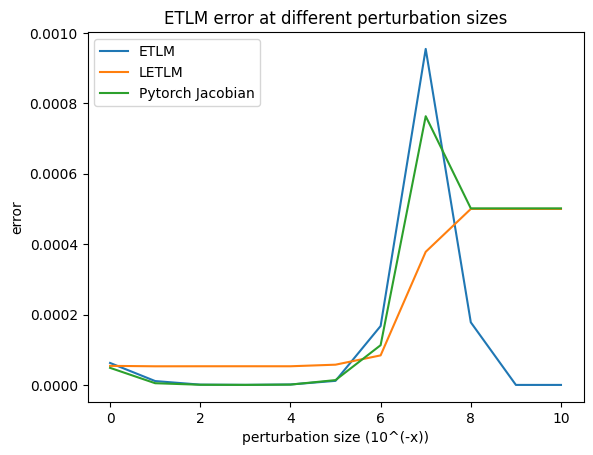

In [37]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes')
plt.legend()

plt.show()

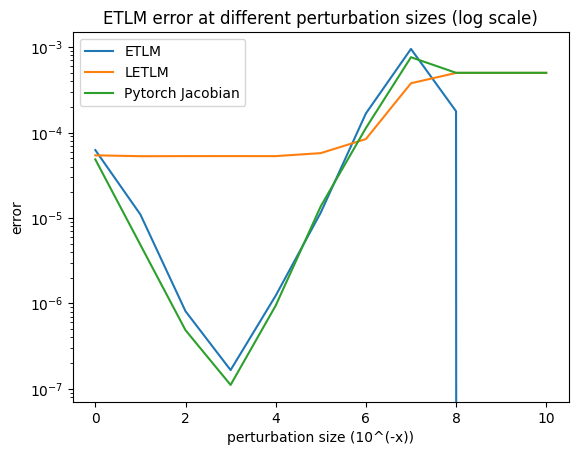

In [38]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

In [39]:
# def little_IETLM(Xi_i, X_i, ensemble_size):
#     # we first define the Pi half matrix
#     Pi_half = torch.cat((Xi_i, -X_i), dim = 1)
#     Pi = Pi_half @ Pi_half.T
#     eigenvals, eigenvecs = torch.lobpcg(Pi, 1)
#     n_i = eigenvecs[0,9]
#     l_i = eigenvecs[9,:]
#     return n_i, l_i

def little_IETLM(Xi_i, X_i):
    # Construct matrix
    Pi_half = torch.cat((Xi_i, -X_i), dim=0)
    Pi = Pi_half @ Pi_half.T
    # print(Pi_half.shape)

    # Compute smallest eigenpair
    eigenvals, eigenvecs = torch.lobpcg(
        Pi,
        k=1,
        largest=False
    )

    # Smallest eigenvector (shape: [18])
    v = eigenvecs[:, 0]

    # Split into two 9-vectors
    n_i = v[:9]
    l_i = v[9:]

    return n_i, l_i



In [40]:
# We will now make the IETLM 
def IETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    # We start by generating the ensemble members
    X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)
    # We now create an empty tensors that will become our N and L matricies
    N_tilde = torch.zeros(N,N)
    L_tilde = torch.zeros(N,N)
    # We now need to calculate the LETLM for each variable in the model 
    for i in tqdm(range(N)):
        # The first step is to select the required ensemble members:
        # We start with the past time step 
        X_i = member_past_selector(i,X,N,ensemble_size)
        # Now the current time step
        Xi_i = member_past_selector(i,Xi,N,ensemble_size)
        # print(Xi_i.shape)
        
        # We now calculate the local LETLM
        n_i, l_i = little_IETLM(Xi_i, X_i)
        # print(l_i)

        # We now need to put M_i into the correct position in M
        N_tilde = put_in_place(n_i, N, N_tilde, i)
        L_tilde = put_in_place(l_i, N, L_tilde, i)

    return N_tilde, L_tilde
        

In [41]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_L96)
ensemble_size = 25
model = bf.crank_nicolson_L96
spin_up_time = 1000
perturbation_size = 10**(-2)
N_tilde, L_tilde = IETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

100%|██████████| 40/40 [00:00<00:00, 708.81it/s]


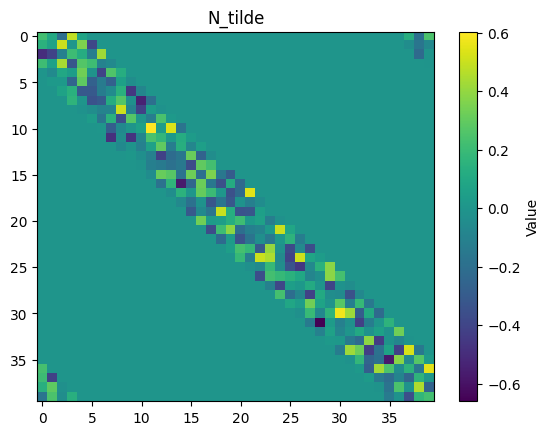

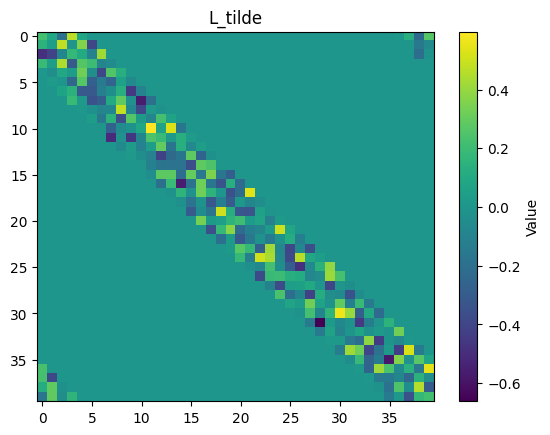

In [42]:
plt.imshow(N_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("N_tilde")
plt.show()
plt.imshow(L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("L_tilde")
plt.show()

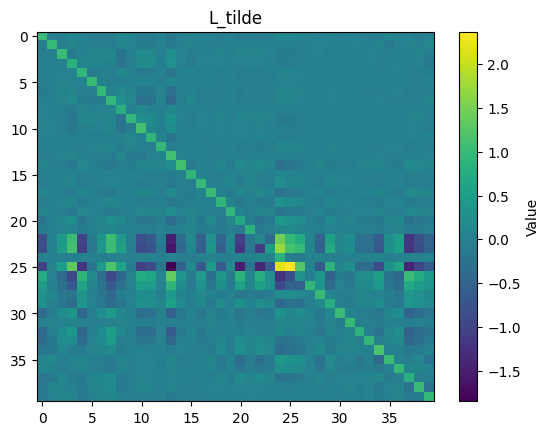

In [43]:
M = torch.inverse(N_tilde) @ L_tilde
plt.imshow(M,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("L_tilde")
plt.show()

In [44]:
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_IETLM = []
trials = 50
for i in perturbations:
    sd = 10**(-1*perturbations[i])
    ensemble_size = 25
    model = bf.crank_nicolson_L96

    # We first need to spin up the model
    N_tilde, L_tilde = IETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)
    IETLM = torch.inverse(N_tilde) @ L_tilde


    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N) * sd

        diff = norm_error(x_g, x_pert, model, IETLM, model_parameters)
        norm = normalisor(x_g, model_parameters, IETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, IETLM, model)
    results_IETLM.append(error/trials)

100%|██████████| 40/40 [00:00<00:00, 766.96it/s]


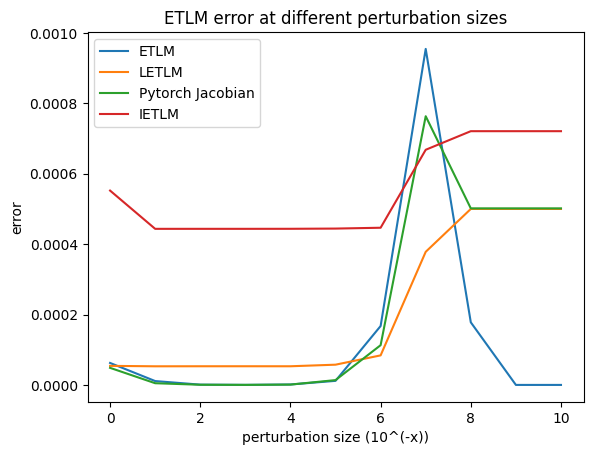

In [45]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )




plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes')
plt.legend()

plt.show()

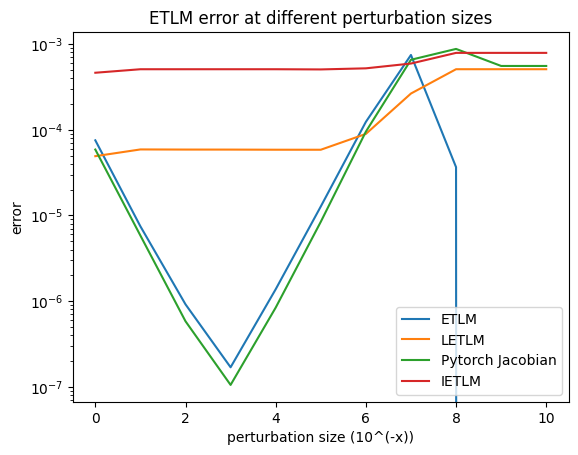

In [ ]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('ETLM error at different perturbation sizes (Log scale)')
plt.legend()

plt.show()